# Recurrent co-mutation pair class-enrichment
각 행의 mutation gene pair를 만들고, pair의 암종별 fold-train log-odds를 26개 점수로 압축한다. C1(P1 대체)이 아닌 P1+pair 26점수 screen이다. 통과 전 C2·추가 결합은 실행하지 않는다.

In [1]:
from pathlib import Path
import subprocess, sys
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py').exists())
RUNNER=ROOT/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'; RESULT=RUNNER.parent.parent/'result'
RUN_ID='exp-comutation-enrichment-01'; SEED=42; RUN_EXPERIMENT=True
# 고정: pair support>=10, alpha=1, shrinkage=20, clip=4, sqrt active-pair normalization

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 395.49it/s]


          variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
P1 multinomial LR      0.527550         8201.2                          0           True                      0      2064.816455
             pair      0.528354         8201.2                          0           True                      0      2064.827018


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds
0,P1 multinomial LR,0.527550,8201.2,0,True,0,2064.816455
1,pair,0.528354,8201.2,0,True,0,2064.827018


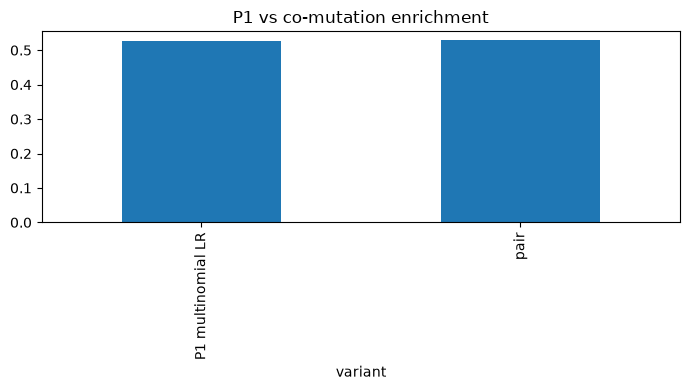

In [2]:
if RUN_EXPERIMENT: subprocess.run([sys.executable,str(RUNNER),'--axis','pair','--seed',str(SEED),'--run-id',RUN_ID],check=True)
import pandas as pd, matplotlib.pyplot as plt
s=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_summary.csv'); assert s.leakage_check.all() and s.nan_as_mutation_count.eq(0).all(); display(s)
s.set_index('variant').oof_macro_f1.plot.bar(figsize=(7,4),title='P1 vs co-mutation enrichment'); plt.tight_layout(); plt.show()